In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from numpy import maximum, sqrt, exp
from datetime import datetime, timedelta
from dateutil.parser import parse
from dateutil.relativedelta import relativedelta
from datetime import datetime, timedelta
from sqlalchemy import create_engine
import scipy.optimize as spop
from scipy import interpolate
import statsmodels.api as sm
import pyodbc


# The Cox, Ingersoll and Ross (CIR)  Model

## The CIR Model Properties



1. <font color='blue'>**Uses**</font> the CIR proces  cannot become negative and has a volatility that is proportional to the level of the variable. These cahracteristics makes it attractive to model vol as is the case with the "Heston model"

1. <font color='blue'>**CIR process dynamics:**</font>  The CIR model is given by <br><br>
$$dX(t) = k \left[ \theta -X(t)\right]dt + \sigma \sqrt{X(t)} dW(t) $$
$
\begin{align}
\text{where }\\
k &: \text{mean reversion rate} \\
\theta  &: \text{long term mean} \\
\sigma  &: \text{short rate volatility}
\end{align}
$ <br><br>

1. <font color='blue'>**CIR process distribution:**</font> The distribution of $X(t)$ conditional on $\mathscr{F}_s$ is non central Chi squared $SNC\chi^2$ <br><br>
$$ X(t) \sim c(t,s) \cdot \chi^2 \left(\delta, \bar K(t,s)\right)$$
$
\begin{align}
\text{where } :&\\
 c(t,s) &= \frac{\sigma^2}{4k}\left( 1 - e^{-k(t-s)} \right)  \\ \\
 \delta &= \frac{4k\theta}{\sigma^2}  \\ \\
 \bar K(t,s) &= \frac{4ke^{-k(t-s)}}{\sigma^2 (1 - e^{-k(t-s)})} r(s)
\end{align}
$
<br>

1. <font color='blue'>**Non central chi squarred distribution $\bar{c} \chi^2(\delta , \lambda)$:**</font> 
    * Let $X_1, X_2,..., X_{\delta}$ be $\delta$ independent normally distributed random variables with means $\mu_i$ and variance $\sigma_i^2$
    
    * Then the random varaiable $$Y = \sum_{i=1}^{\delta} \left( \frac{X_i}{\sigma_i}\right)^2 $$ is distibuted according to the noncentral chi-squared distribution
    
    * The parameter $\delta$ define the degree of freedom (a.k.a the numbers of $X_i$)
    
    * the parameter $\bar K$ called the non centrality parameter is defined by $$\bar K =  \sum_{i=1}^{\delta} \left( \frac{\mu_i}{\sigma_i}\right)^2$$
    <br><br>

1. <font color='blue'>**Feller condition:**</font> The parameters must satisfy that the degree of freedom of the distribution is at least 2 to ensure that $X(t)$ is not negatif. That is :    $$\delta =\dfrac{4k\theta}{\sigma^2} > 2$$
<br>

1. Note that in python the non central chi squared distribution is available in scipy.stats.ncx2 see (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ncx2.html)
    * $\text{degree of freedom} \Leftrightarrow \text{df} \Leftrightarrow \delta$
    * $\text{non-centrality parameter} \Leftrightarrow \text{nc} \Leftrightarrow \bar K(t,s)$
    * $\text{scale}  \Leftrightarrow c(t,s)$
    <br><br>

1. if the Feller condition is not true the origine is accessible and strongly reflecting (see Feller & Cox paper 1985) <br>
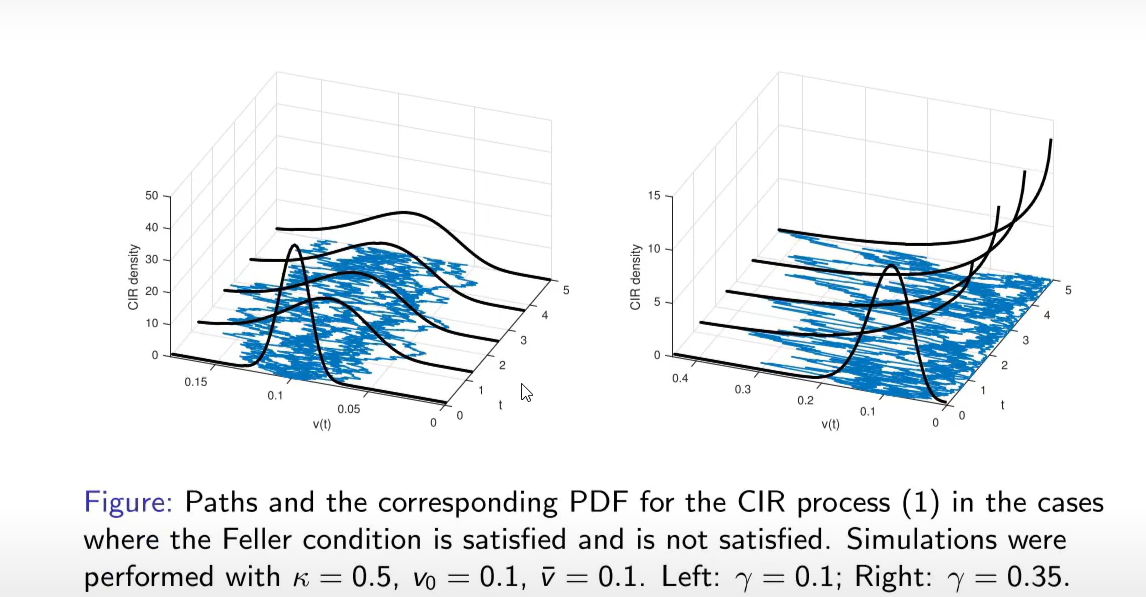 <br><br>

1. probability negative value with discretization <br>
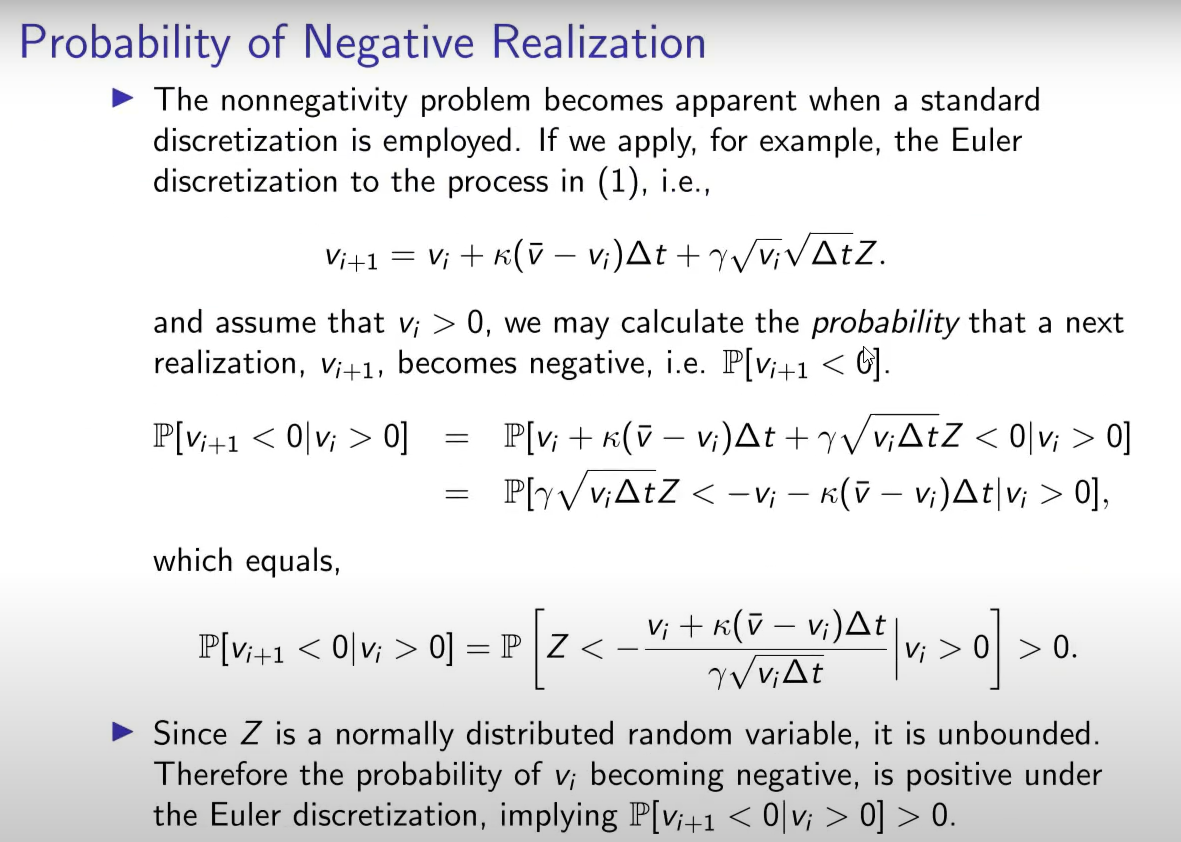<br><br>

1. Reflecting vs truncated Euler discretization <br>
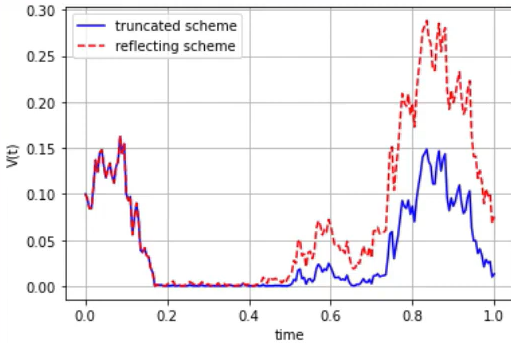<BR><BR>
    
1. <font color='blue'>**Short rate dynamics under $\mathbb{Q}$:**</font>  The CIR model is given by <br><br>
$$dr(t) = k \left[ \theta -r(t)\right]dt + \sigma \sqrt{r(t)} dW^{\mathbb{Q}}(t) $$
$
\begin{align}
\text{where }\\
k &: \text{mean reversion rate} \\
\theta  &: \text{long term mean} \\
\sigma  &: \text{short rate volatility}
\end{align}
$ <br><br>

1. <font color='blue'>**Short rate distribution under $\mathbb{Q}$:**</font> The distribution of the short rate $r(t)$ conditional on $\mathscr{F}_s$ is non central Chi squared $SNC\chi^2$ <br><br>
$$ r(t) \sim c(t,s) \cdot \chi^2 \left(\delta, \bar K(t,s)\right)$$

1. <font color='blue'>**Short rate dynamics under $\mathbb{T}$:**</font>  The CIR model is given by <br><br>
$$dr(t) = \left[ k\theta -\right(k + B(t,T)\sigma^2\left)r(t)\right]dt + \sigma \sqrt{r(t)} dW^{\mathbb{T}}(t) $$ 
<br> Where the change of measure is done via
$$dW^{\mathbb{T}}(t) = dW^{\mathbb{Q}}(t) + \sigma B(t,T)\sqrt{r(t)}dt$$ <br><br>

1. <font color='blue'>**Dynamics under  $\mathbb{P}$:**</font> under the real world measure we have <br><br>
$$dr(t) = \left[ k \theta -\left( k + \lambda \sigma\right) r(t)  \right]dt + \sigma \sqrt{r(t)} dW^{\mathbb{P}}(t) $$
<br>
Where we assume the market price of risk is of the form 
$
\begin{align}
 &\lambda(t) = \lambda \sqrt{r(t)}dt
\end{align}
$<br>
where we assume the market price of risk is of the form he parameter $\lambda$ and $\sigma$ could be estimated from historical data
<br><br>

1. <font color='blue'>**Affine properties:**</font> <br><br>
$$P(t,T) = A(t,T)e^{-B(t,T)r(t)}$$
<br>
Where
$$
\begin{align}
B(t,T) &= \dfrac{2 \left( e^{ (T-t)h } -1 \right) }{  2h + (k+h) \left( e^{ (T-t)h } -1 \right)                 } \\
\\
A(t,T) &=   \left[     \dfrac{     2h e^{  (k+h)(T-t)/2  }  }    {    2h + (k+h) \left( e^{ (T-t)h } -1 \right)     }                                              \right]^{2k\theta/\sigma^2} \\
\\
h &= \sqrt{k^2 + 2\sigma^2}
\end{align}
$$
<br><br>

1. <font color='blue'>**Zero Bond Option pricing:**</font> The price at time $t$ of The Zero Bond Option price can be found analytically as <br><br>
$$\text{ZBO}(t, T, S, X) = P(t,S) \chi^2\left(   2\bar{r}[\rho + \psi + B(T,S)];  \dfrac{4k\theta}{\sigma^2},  \dfrac{2\rho^2 r(t)e^{h(T-t)}}{\rho + \psi+ B(T,S)}  \right) - X P(t,T) \chi^2\left(   2\bar{r}[\rho + \psi];  \dfrac{4k\theta}{\sigma^2},  \dfrac{2\rho^2 r(t)e^{h(T-t)}}{\rho + \psi}  \right)  $$ <br>
where
    * $\rho = \dfrac{2h}{\sigma^2\left(    e^{h(T-t)}  -1   \right)}$
    * $\psi = \dfrac{k+h}{\sigma^2}$
    * $\bar{r} = \dfrac{\text{ln}(A(T,S)/X)}{B(T,S)}$
<br><br>
1. <font color='blue'>**Possible shapes:**</font> <br>
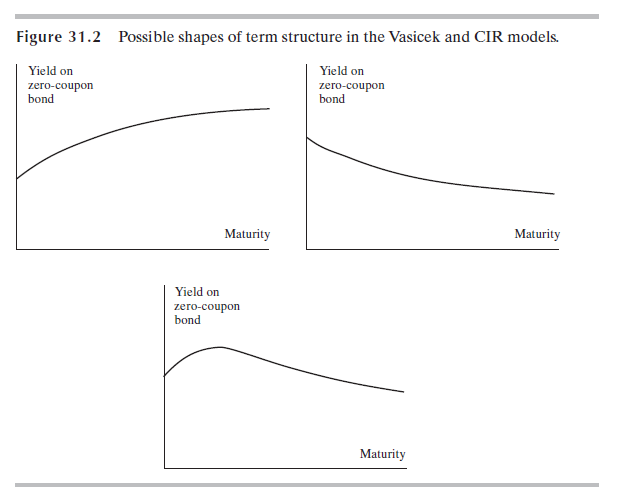

## Calibration 


### Data collection and setup

In the codde below we: 
1. Get the SDR curve nodes from our database

1. Fit a yiled curve through the terms using spline interpolation

1. define the affine functions $A$ and $B$ to compute the price of zero coupon bonds

1. define a function that returns historical Rates from our database

,Date,R
3585,2023-10-11,0.042639
3586,2023-10-12,0.042675
3587,2023-10-13,0.042573
3588,2023-10-16,0.042705
3589,2023-10-18,0.042787


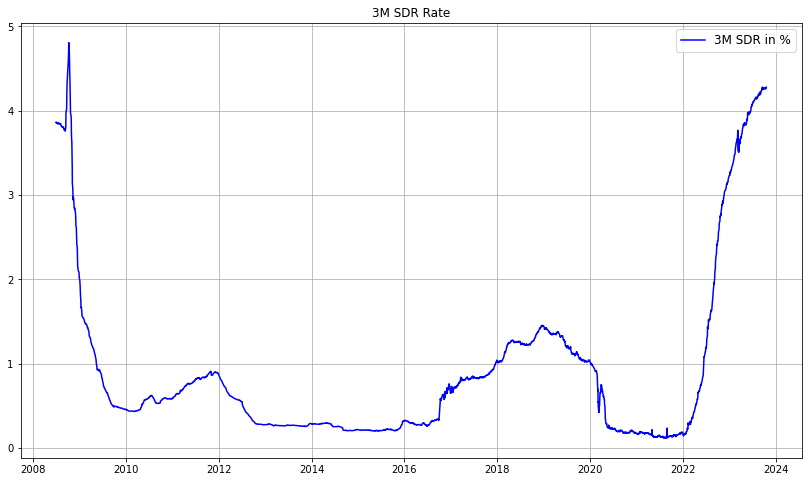

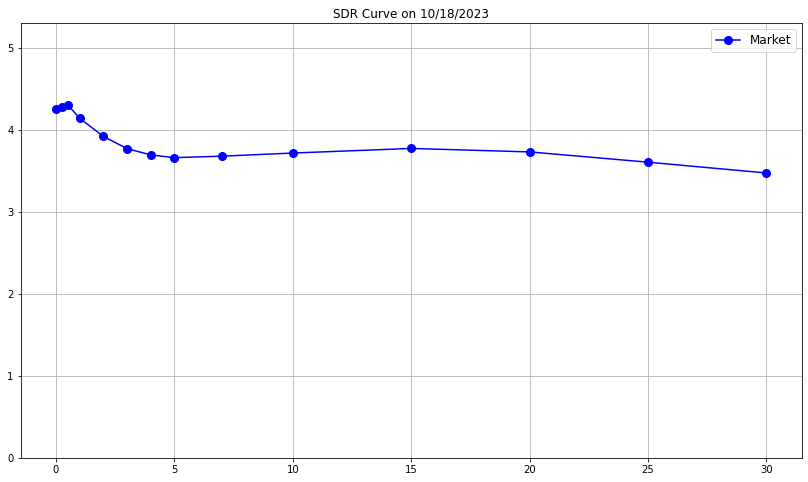

In [2]:
# Define the date for which we want to extract the yield curve
data_date = '10/18/2023'
node = '3M'

# database configuration
db_name = 'PyDB_prod'
server_name = r"wbmsmc101\marketrisk"
connection_str =f"mssql+pyodbc://{server_name}/{db_name}?driver=SQL+Server+Native+Client+11.0"
#conn = create_engine(connection_str).connect()
conn = pyodbc.connect('Driver={SQL Server};'
                      'Server=WBMSMC101\MARKETRISK;'
                      'Database=CROMCDB;'
                      'Trusted_Connection=yes;'
                      'Username=WB\WB548956;')

# this function compute the yield befind a zero coupon bond z
def zero_coupon_to_yield(T, z):
    return -np.log(z)/T*100

def P_cir(t, T, k, θ, σ, r_t):
    """
    :param t: valuation date
    :param T: Payment date of ZCB
    :return:
    """
    h = np.sqrt(k ** 2 + 2 * σ ** 2)
    
    def A(t, T): 
        numerator = 2 * h * np.exp(0.5 * (k + h) * (T-t))
        denumerator = 2 * h + (k + h) * (np.exp(h * (T-t)) - 1) 
        exponent = 2 * k * θ / σ ** 2
        return (numerator / denumerator) ** exponent

    def B(t, T):
        numerator = 2 * (np.exp(h * (T-t)) - 1)
        denumerator = 2 * h + (k + h) * (np.exp(h * (T-t)) - 1) 
        return numerator / denumerator

    P_t_T = A(t, T) * exp(- B(t, T) * r_t)
    return P_t_T

# This function gets historical data
def get_hist_data(DATE, CCY, NODE, nbr_days_calib = 250*100, plot_curve = True ):
    # database configuration and getting the data
    db_name = 'PyDB_prod'
    server_name = r"wbmsmc101\marketrisk"
    connection_str = f"mssql+pyodbc://{server_name}/{db_name}?driver=SQL+Server+Native+Client+11.0"
    conn = pyodbc.connect('Driver={SQL Server};'
                      'Server=WBMSMC101\MARKETRISK;'
                      'Database=CROMCDB;'
                      'Trusted_Connection=yes;'
                      'Username=WB\WB548956;')
    
    sql = f""" select * from 
         (
         SELECT top {nbr_days_calib} 
        [Date] ,[Rate(%)]/100 AS R 
            FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy] where CCY = '{CCY}' AND Node = '{NODE}'  AND [Date] <= '{DATE}' ORDER BY DATE desc) as A
            order by Date """
    yield_curve_data = pd.read_sql(sql, conn) 
    display(yield_curve_data.tail())
    
    if plot_curve:
        # plot historical data
        fig = plt.figure(figsize=(14,8)) 
        ax = fig.add_subplot(1,1,1) 
        ax.plot(yield_curve_data['Date'],yield_curve_data['R']*100, linestyle='-', color = 'b',  label = f"{NODE} {CCY} in %" )
        ax.set_title(f'{NODE} SDR Rate'); 
        plt.grid()
        ax.legend(fontsize = 'large');
    
    return yield_curve_data

hist_data = get_hist_data(DATE = data_date , CCY = 'SDR', NODE =node, nbr_days_calib = 250*100, plot_curve = True )

# Define the sql query used to get the SDR yield curve
sql = f""" SELECT Date,Node, [t],[Rate(%)] as r FROM [PyDB_Prod].[dbo].[SDR_Curves_by_ccy]  where date = '{data_date}'  and CCY = 'SDR' Order by t """

# read the data into a dataframe
yield_curve_data = pd.read_sql(sql,conn)
yield_curve_data['Date'] = yield_curve_data.Date.apply(lambda x: x.date())

# convert the ineterat rates to zero coupon bonds 
yield_curve_data['P(0,T)'] =  np.exp(-yield_curve_data.r*yield_curve_data.t/100.0)   

# Create the yield curve function y(t) using linear interpolation
interpolator = interpolate.splrep(yield_curve_data.t, yield_curve_data.r )
y = lambda t : interpolate.splev(t,interpolator,der=0)

# define the zero coupon bond curve based on the yield curve
P0T_market = lambda T : np.exp(-y(T)/100*T)

# Plot the zero coupon bond curves   
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'], y(yield_curve_data['t']), linestyle='-', color = 'b', marker='o', markersize=8,  label = 'Market');
ax.set_title(f'SDR Curve on {data_date}'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large');



### $\mathbb{Q}$ - Calibration : Fitting current yield curve


First we defined the objective function
* Let $P(t,T)$ : be the market value of zero coupon bond maturing at time $T$
* Let $\hat P(\Theta; t,T)$ : be the model value of the ZCB given parameter $\Theta$

we want to minimize the root mean squared error RMSE where 

$$ \epsilon = \hat P(\Theta; t,T) - P(t,T)  $$

In [3]:
def cir_obj(params):
    k = params[0]
    θ = params[1]
    σ = params[2]
    r0 = params[3]
    
    P0T_martket_zeroes = P0T_market(yield_curve_data.t)
    P0T_model_zeroes =P_cir(0,yield_curve_data.t, k,θ, σ,r0 ) 
    
    model_zeroes = zero_coupon_to_yield(yield_curve_data['t'], P0T_model_zeroes )
    martket_zeroes = zero_coupon_to_yield(yield_curve_data['t'],P0T_martket_zeroes)

    ϵ = model_zeroes - martket_zeroes
    squared_errors = ϵ**2
    rmse = np.sqrt(squared_errors.mean())
    return rmse

Here we use Optimization routine to find the parameters

In [4]:
k_init = 0.1  # lamba the mean reversion rate
θ_init = hist_data.R.mean()
σ_init = hist_data.R.std()
r0_init = hist_data.R.values[-1]

cons = (
    {'type': 'ineq', 'fun' : lambda x:  x[2] }, # Vol must be positive
    {'type': 'ineq', 'fun' : lambda x: 2*x[0]*x[1] -x[2]**2 } # feller condition
        
        )

res = spop.minimize(fun=cir_obj,
                    x0=[k_init, θ_init, σ_init, r0_init],
                    bounds=[(0.000001, 1), (-0.1, 0.1), (0.0001, 1), (0, 1)],
                    constraints= cons
                    )

params = res.x


k = params[0]
θ = params[1]
σ = params[2]
r0 = params[3]

print(f""" The optimal parameters for vacisek are :
k = {k}
θ = {θ}
σ = {σ}
r0 = {r0}
the rmse is : {round(res.fun,2)}%
""")

C:\wbg\Anaconda3\lib\site-packages\scipy\optimize\optimize.py:282: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  warnings.warn("Values in x were outside bounds during a "


 The optimal parameters for vacisek are :
k = 0.03316705415442423
θ = 0.02405479372688124
σ = 0.00010012213079678589
r0 = 0.04052483663652273
the rmse is : 0.18%



Plot curves

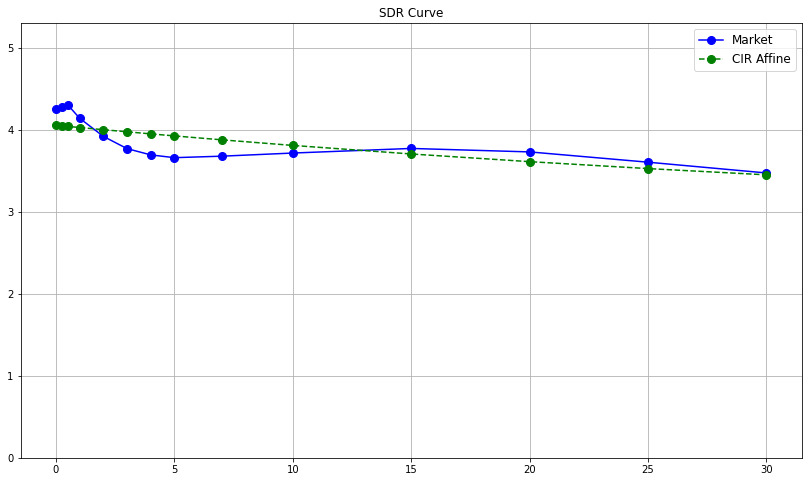

In [5]:
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'],
        y(yield_curve_data['t']),
        linestyle='-',
        color = 'b',
        marker='o',
        markersize=8,
        label = 'Market');
plt.grid()

ax.plot(yield_curve_data['t'],
        zero_coupon_to_yield(yield_curve_data['t'], P_cir(0,yield_curve_data['t'], k, θ, σ, r0) ),
        linestyle='--',
        color = 'g', 
        marker='o', 
        markersize=8, 
        label = 'CIR Affine');

ax.set_title('SDR Curve'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large')
plt.grid()

### $\mathbb{P}$ - Calibration 


#### $\mathbb{P}$ - Calibration strategy


1. We estimate the parameters of the vasicek model in $\mathbb{P}$ using historical data  

1. The list of parameters are 

    * $\lambda$ as the market price of risk
    * $k$ as the mean reversion rate
    * $\theta$ -the long term short rate
    * $\sigma$ the volatility parameter
    * $r_0 = $ short rate
    <br><br>
    
1. we consider the historical data for example of SDR 1D as a proxy of the short rate

1. from the historical method we can find
    * $r_0 = $ as the current short rate in the time series
    * $\sigma$ as the volatility does not change between different measure <br><br>

1. We can find $k$ and $\theta$ by
    * fitting to instruments found in the market 
    * using $r_0$ and $\sigma$ as constant in optimization <br><br>
   
1. finally we can find the market price of risk   


#### OLS Calibration method


1. Remember we have 
$$
\begin{align}
dr(t) &= \left[ b -a\cdot r(t)  \right]dt + \sigma \sqrt{r(t)} dW^{\mathbb{P}}(t) \\ \\
dr(t) &=  \left[ k \theta -( k + \lambda \sigma) r(t)  \right]dt + \sigma \sqrt{r(t)} dW^{\mathbb{P}}(t) 
\end{align}
$$

1. We can rewrite as 
$$
\begin{align}
\dfrac{r_t - r_{t-1}}{\sqrt{r_{t-1}}} &= \dfrac{1}{\sqrt{r_{t-1}}}b\Delta_t  -a\Delta_t \cdot \sqrt{r_{t-1}}  + \sigma  z \sqrt{\Delta_t}  \\
\end{align}
$$

1. Lets call <br>
$
\begin{align}
y(t) &= \dfrac{r_t - r_{t-1}}{\sqrt{r_{t-1}}}  \\ \\
x_1(t) &= \dfrac{1}{\sqrt{r_{t-1}}} \\\\
x_2(t) &= \sqrt{r_{t-1}}
\end{align}
$

1. in regression term this is equivalent to  
$$
\begin{align}
y &= b\Delta_t x_1  - a \Delta_t x_2 + \sigma z \sqrt{\Delta_t} \\
y &= \beta_1 x_1  + \beta_2 x_2 + \epsilon\\
\end{align}
$$

1. Hence by regressing the change in short rate against the short rate we find
    * $\beta_1 = b\Delta_t = k\theta \Delta_t $
    
    * $\beta_2 = - a\Delta_t = -( k + \lambda \sigma) \Delta_t$
    
    * residual error = $\sigma \sqrt{\Delta_t}$ <br><br>
    
    
1. as we can see from the code below we can readily find $r_0$ and $\sigma$ then use the strategy described in the section above

1. In fitting to instrument we may set as constraint:  $k\times \theta = b$


                                 OLS Regression Results                                
Dep. Variable:                      Y   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.000
Method:                 Least Squares   F-statistic:                             0.4528
Date:                Wed, 19 Jun 2024   Prob (F-statistic):                       0.636
Time:                        02:55:50   Log-Likelihood:                          17830.
No. Observations:                3589   AIC:                                 -3.566e+04
Df Residuals:                    3587   BIC:                                 -3.564e+04
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

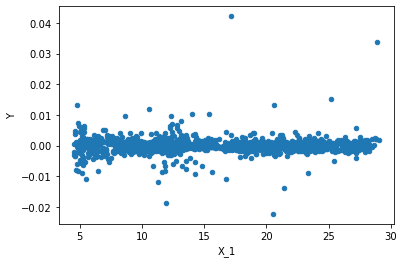

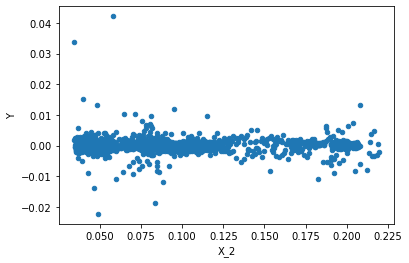

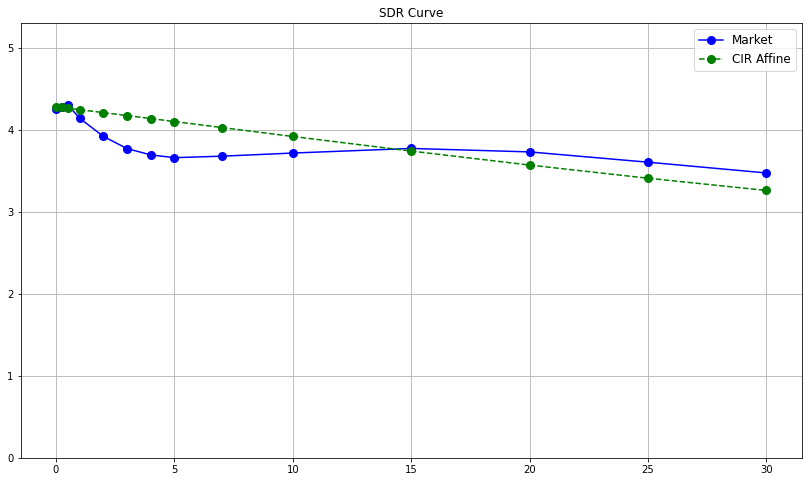

In [6]:
# define objective function with just two parameters k and θ
def CIR_obj_v2(params):
    k = params[0]
    θ = params[1]
    
    P0T_martket_zeroes = P0T_market(yield_curve_data.t)
    P0T_model_zeroes =P_cir(0,yield_curve_data.t, k,θ, σ,r0 ) 
    
    model_zeroes = zero_coupon_to_yield(yield_curve_data['t'], P0T_model_zeroes )
    martket_zeroes = zero_coupon_to_yield(yield_curve_data['t'],P0T_martket_zeroes)

    ϵ = model_zeroes - martket_zeroes
    squared_errors = ϵ**2
    rmse = np.sqrt(squared_errors.mean())
    return rmse

# Finding optimal parameters by linear regression
Δt = 1 / 250.0
hist_data['Δr_actual'] = hist_data.R.diff()
hist_data['r_lag'] = hist_data.R.shift()
hist_data.dropna(inplace=True)
hist_data['X_2'] = np.sqrt(hist_data.r_lag)
hist_data['X_1'] = 1 / hist_data['X_2']
hist_data['Y'] = hist_data.Δr_actual / hist_data['X_2']


mod = sm.OLS(hist_data.Y, hist_data[[ 'X_1', 'X_2',]])
res = mod.fit()

hist_data.plot(kind = 'scatter', x = 'X_1', y = 'Y' )
hist_data.plot(kind = 'scatter', x = 'X_2', y = 'Y' )

print(res.summary())

β_1 = res.params[0]
β_2 = res.params[1]

b = β_1 / Δt
a = -β_2 / (Δt)
σ = res.resid.std() / sqrt(Δt)

# get the rates ts r_1, r_2, ...r_n
r = np.array(hist_data.R)
r0 = r[-1]

θ_init = hist_data.R.mean()
k_init = b/ θ_init  # lamba the mean reversion rate



cons = ({'type': 'ineq', 'fun' : lambda x: 2*x[0]*x[1] - σ**2 }, #feller condition
       {'type': 'eq', 'fun': lambda x: x[0]*x[1] - b },  # θ = 4% constraint
        
        )


res = spop.minimize(fun=CIR_obj_v2,
                    x0=[k_init, θ_init],
                    bounds=[(0.000001, 1), (0, 1)],
                    constraints= cons
                    )

params = res.x

k = params[0]
θ = params[1]
λ = (a - k)/σ

print(f"""
-------------------------------------
β_1 = {β_1}
β_2 = {β_2}
b = {b}
a = {a}
k = {k}
θ = {θ}
σ = {σ}
r0 = {r0}
λ = {λ}
the rmse is : {round(res.fun,3)}%
""")

fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'],
        y(yield_curve_data['t']),
        linestyle='-',
        color = 'b',
        marker='o',
        markersize=8,
        label = 'Market');
plt.grid()

ax.plot(yield_curve_data['t'],
        zero_coupon_to_yield(yield_curve_data['t'], P_cir(0,yield_curve_data['t'], k, θ, σ, r0) ),
        linestyle='--',
        color = 'g', 
        marker='o', 
        markersize=8, 
        label = 'CIR Affine');

ax.set_title('SDR Curve'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large')
plt.grid()

## Paths Generation 


1. <font color='blue'>**Short rate dynamics under $\mathbb{Q}$:**</font>  The CIR model is given by <br><br>
$$dr(t) = k \left[ \theta -r(t)\right]dt + \sigma \sqrt{r(t)} dW^{\mathbb{Q}}(t) $$
$
\begin{align}
\text{where }\\
k &: \text{mean reversion rate} \\
\theta  &: \text{long term mean} \\
\sigma  &: \text{short rate volatility}
\end{align}
$ <br><br>
​
1. <font color='blue'>**Feller condition:**</font> The parameters must satisfy the following inequality to ensure that $r(t)$ is not negatif    $$2k\theta > \sigma^2$$
<br>
​
1. <font color='blue'>**Short rate distribution under $\mathbb{Q}$:**</font> The distribution of the short rate $r(t)$ conditional on $\mathscr{F}_s$ is non central Chi squared $SNC\chi^2$ <br><br>
$$ r(t) \sim c(t,s) \cdot \chi^2 \left(\delta, \bar K(t,s)\right)$$
$
\begin{align}
\text{where } :&\\
 c(t,s) &= \frac{\sigma^2}{4k}\left( 1 - e^{-k(t-s)} \right)  \\ \\
 \delta &= \frac{4k\theta}{\sigma^2}  \\ \\
 \bar K(t,s) &= \frac{4ke^{-k(t-s)}}{\sigma^2 (1 - e^{-k(t-s)})} r(s)
\end{align}
$
<br>

1. In the following we genrate the path via exact, euler and milstein methods

1. Note here the euler and milstein path are equivalent beacuse the diffusion term is a constant


### Exact vs Euler vs Milstein


C:\Users\wb548956\AppData\Local\Temp/ipykernel_26540/3899536265.py:43: RuntimeWarning: invalid value encountered in sqrt
  r_t = r_s +  k*(θ - r_s) * dt + σ*sqrt(r_s)  * dWt
C:\Users\wb548956\AppData\Local\Temp/ipykernel_26540/1129370654.py:18: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100
C:\Users\wb548956\AppData\Local\Temp/ipykernel_26540/1129370654.py:18: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100
C:\Users\wb548956\AppData\Local\Temp/ipykernel_26540/1129370654.py:18: RuntimeWarning: invalid value encountered in true_divide
  return -np.log(z)/T*100


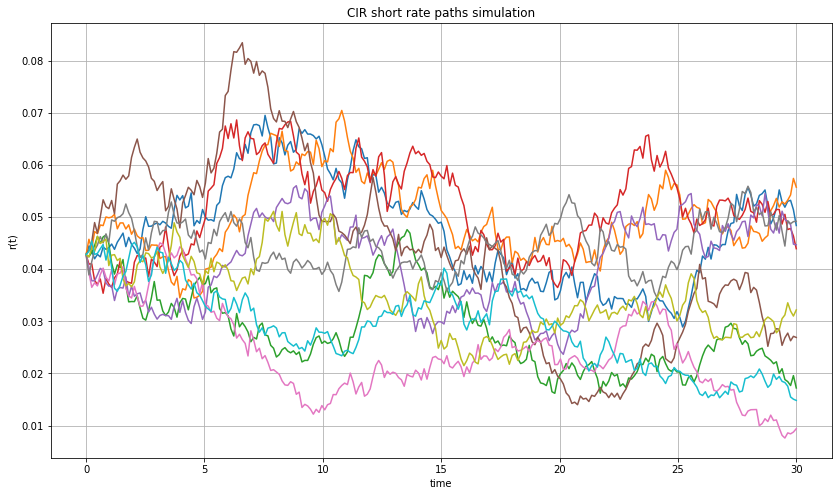

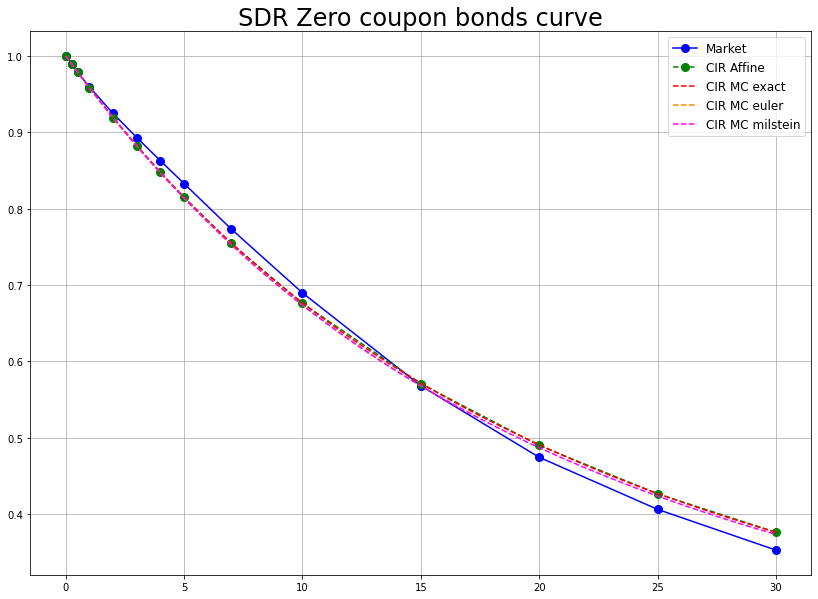

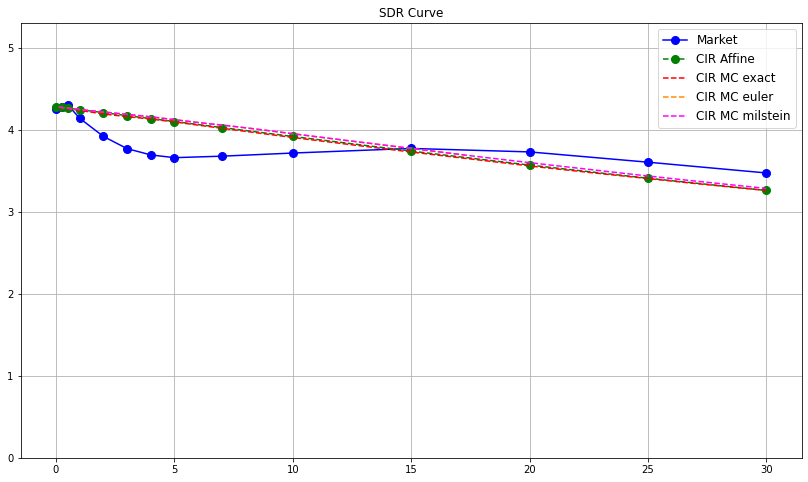

In [7]:
# k = 0.9836217862402499
# θ = 0.035827894434068704
# σ = 0.00269153072059649
# r0 = 0.04350666181104503

M = 1_000
N = 250
T = 30

Z = np.random.normal(0.0,1.0,[M ,N ])
W = np.zeros([M , N +1])

r_exact = np.zeros([M , N +1])
r_euler = np.zeros([M , N +1])
r_milstein = np.zeros([M , N +1])

r_exact[:,0]  = r0
r_euler[:,0]  = r0
r_milstein[:,0]  = r0

M_t_exact = np.zeros([M, N+1])
M_t_euler = np.zeros([M, N+1])
M_t_milstein = np.zeros([M, N+1])

M_t_exact[:,0] = 1
M_t_euler[:,0] = 1
M_t_milstein[:,0] = 1

t = np.zeros([N+1]) # time
dt = T / float(N)


def cir_exact_paths(k, θ, σ,s, t,  r_s):
    δ = 4 * k *θ/(σ**2)
    c = σ**2 / (4*k) * (1 - exp(-k* (t-s) )  )
    K = 4 * k * r_s * exp( -k * (t-s) ) / ( σ**2 * (1 - exp(-k * (t-s) ) ) )
    r_t = c * np.random.noncentral_chisquare(δ, K)
    return r_t

def cir_euler_paths(k, θ, σ,s, t,  r_s, z):
    dt = t-s
    dWt = z*sqrt(dt)
    r_t = r_s +  k*(θ - r_s) * dt + σ*sqrt(r_s)  * dWt
    return r_t

def cir_milstein_paths(k, θ, σ,s, t,  r_s, z):
    dt = t-s
    dWt = z*sqrt(dt)
    r_t = r_s +  k*(θ - r_s) * dt + σ*sqrt(r_s)  * dWt + 0.5* σ*sqrt(r_s)  * (dWt **2 - dt) * (0.5 *σ *r_s**(-0.5))
    return r_t

for i in range(0,N):
    t[i+1] = t[i] + dt
    
    r_exact[:,i+1] = cir_exact_paths(k, θ, σ,t[i], t[i + 1],  r_exact[:, i] )
    r_euler[:,i+1] = cir_euler_paths(k, θ, σ,t[i], t[i + 1],  r_euler[:, i],Z[:,i] )
    r_milstein[:,i+1] = cir_milstein_paths(k, θ, σ,t[i], t[i + 1],  r_milstein[:, i],Z[:,i] )
    
    M_t_exact[:, i+1] = M_t_exact[:,i] * np.exp( (r_exact[:, i+1] + r_exact[:, i])* 0.5 * dt)
    M_t_euler[:, i+1] = M_t_euler[:,i] * np.exp( (r_euler[:, i+1] + r_euler[:, i])* 0.5 * dt)
    M_t_milstein[:, i+1] = M_t_milstein[:,i] * np.exp( (r_milstein[:, i+1] + r_milstein[:, i])* 0.5 * dt)
    
    
    
P_t_exact = np.mean(1.0/M_t_exact, axis = 0)
P_t_euler = np.mean(1.0/M_t_euler, axis = 0)
P_t_milstein = np.mean(1.0/M_t_milstein, axis = 0)
P_affine = P_cir(0,yield_curve_data['t'], k, θ, σ, r0)

    
fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(t, np.transpose(r_milstein[:10,:]), linestyle='-')
plt.grid()
plt.xlabel("time")
plt.ylabel("r(t)");
ax.set_title('CIR short rate paths simulation'); 

fig = plt.figure(figsize=(14,10)) # create a figure where we will put our plots
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
#x.plot(yield_curve_data['t'], yield_curve_data[''], linestyle='-', color = 'r');
ax.plot(yield_curve_data['t'], P0T_market(yield_curve_data['t']), linestyle='-', color = 'b', marker='o', markersize=8,label = 'Market');
ax.plot(yield_curve_data['t'],  P_affine, linestyle='--', color = 'g', marker='o', markersize=8 , label = 'CIR Affine');
ax.plot(t, P_t_exact, linestyle='--', color = 'r',label = 'CIR MC exact');
ax.plot(t, P_t_euler, linestyle='--',color = 'darkorange', label = 'CIR MC euler');
ax.plot(t, P_t_milstein, linestyle='--',color = 'magenta', label = 'CIR MC milstein');

ax.set_title('SDR Zero coupon bonds curve', fontsize = 24); 
ax.legend(fontsize = 'large')
plt.grid()
# plt.ylim([0,max(P0T_market(yield_curve_data['t']))*1.1])


fig = plt.figure(figsize=(14,8)) # create a figure where we will put our plots
 # create a subplot with 1 axis
#x.plot(yield_curve_data['t'], yield_curve_data[''], linestyle='-', color = 'r');
ax = fig.add_subplot(1,1,1) # create a subplot with 1 axis
ax.plot(yield_curve_data['t'], y(yield_curve_data['t']), linestyle='-', color = 'b', marker='o', markersize=8,  label = 'Market');
ax.plot(yield_curve_data['t'], zero_coupon_to_yield(yield_curve_data['t'], P_affine ), linestyle='--', color = 'g', marker='o', markersize=8, label = 'CIR Affine');
ax.plot(t,zero_coupon_to_yield( t, P_t_exact), linestyle='--', color = 'r', label = 'CIR MC exact');
ax.plot(t,zero_coupon_to_yield( t, P_t_euler), linestyle='--', color = 'darkorange', label = 'CIR MC euler');
ax.plot(t,zero_coupon_to_yield( t, P_t_milstein), linestyle='--',  color = 'magenta', label = 'CIR MC milstein');

ax.set_title('SDR Curve'); 
plt.grid()
plt.ylim([0,max( y(yield_curve_data['t']))+1])
ax.legend(fontsize = 'large');

### Paths error analysis


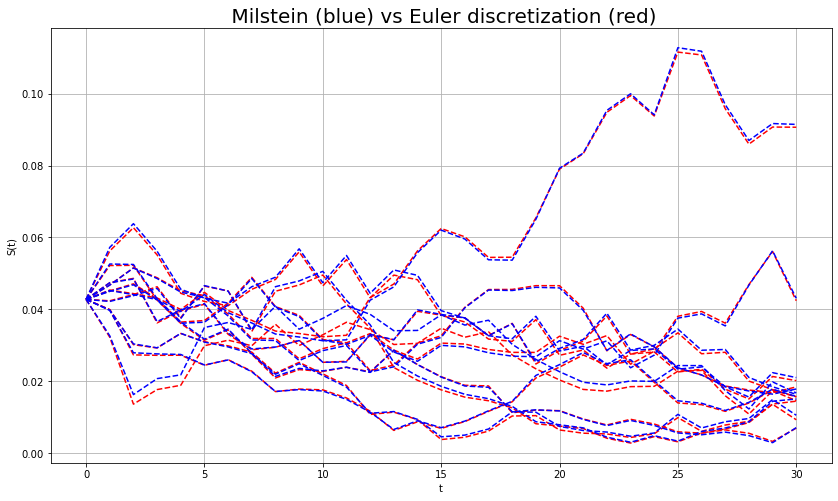

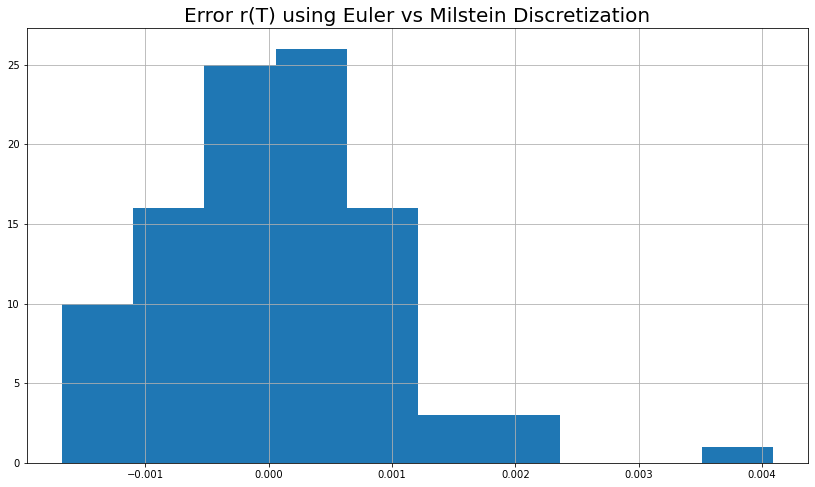

In [8]:


M = 1_00
N = 30
T = 30
dt = T / float(N)

t = np.zeros([N+1]) # time
Z = np.random.normal(0.0,1.0,[M ,N ])

r_exact = np.zeros([M , N +1])
r_euler = np.zeros([M , N +1])
r_milstein = np.zeros([M , N +1])

r_exact[:,0]  = r0
r_euler[:,0]  = r0
r_milstein[:,0]  = r0


for i in range(0,N):
    t[i+1] = t[i] + dt
    r_exact[:,i+1] = cir_exact_paths(k, θ, σ,t[i], t[i + 1],  r_exact[:, i] )
    r_euler[:,i+1] = cir_euler_paths(k, θ, σ,t[i], t[i + 1],  r_euler[:, i], Z[:,i] )
    r_milstein[:,i+1] = cir_milstein_paths(k, θ, σ,t[i], t[i + 1],  r_milstein[:, i],Z[:,i] )
    
exact_S =  r_exact
euler_S =  r_euler
milstein_S = r_milstein

euler_S_T = euler_S[:,-1]
exact_S_T = exact_S[:,-1]
milstein_S_T = milstein_S[:,-1]

plt.figure( figsize = (14,8))
plt.plot(t, np.transpose(euler_S[0:10,:]),color = 'red', linestyle = 'dashed', label = 'Euler Paths')   
plt.plot(t, np.transpose(milstein_S[0:10,:]),color = 'blue', linestyle = '--', label = 'Milstein Paths') 

plt.grid()
plt.xlabel("t")
plt.ylabel("S(t)")
plt.title(' Milstein (blue) vs Euler discretization (red)', fontsize=20 );

plt.figure(figsize = (14,8))
plt.hist( milstein_S_T - euler_S_T)
plt.grid()
plt.title('Error r(T) using Euler vs Milstein Discretization', fontsize=20 );



## Test comparing numpy noncentral_chisquare vs scipy ncx2

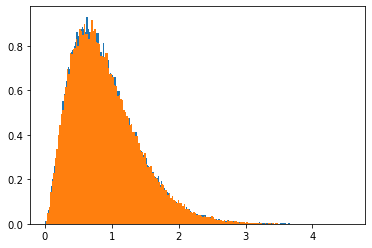

In [9]:
from numpy.random import noncentral_chisquare
from scipy.stats import ncx2

d= 5
k = 4
c = 0.1

A = ncx2.rvs(d,k, scale= c ,size = 100_000)
B = ncx2.rvs(d,k, scale= c, loc= 0 ,size = 100_000)

values_A = plt.hist(A, bins=200, density=True)
values_B = plt.hist(B, bins=200, density=True)
